# 2. Fitting exerimental data to constitutive models

In this notebook, we use ForceIndent-JAX to to fit data from force-indentation experiments to various viscoelastic constitutive models. 

In [1]:
%run _common.ipynb
%matplotlib inline
from pathlib import Path

import equinox as eqx
import jax.numpy as jnp
from jaxtyping import PyTree, Array, Float
import matplotlib.pyplot as plt

from neuralconstitutive.io import import_data, normalize_dataset, truncate_adhesion
from neuralconstitutive.tipgeometry import Spherical
from neuralconstitutive.indentation import IndentationBuilder, ConstantVelocity
from neuralconstitutive.constitutive import AbstractConstitutive,StandardLinearSolid, ModifiedPowerLaw, PowerLaw, GeneralizedMaxwellmodel, DoublePowerLaw
from neuralconstitutive.ting.numerical import force_approach, force_retract, force_ting
from neuralconstitutive.ting.analytic import force_powerlaw
from neuralconstitutive.fitting import least_squares, sample_params_lhs, make_transformation_function
from neuralconstitutive.plotting import MM

## Import and preprocess experimental data

In [2]:
speed = 5
file_index = 0

# Import data
datadir = Path(f"../data/abuhattum_iscience_2022/PAAM hydrogel/speed {speed}")
name_suffix = "" if file_index == 0 else f"_{file_index}"
filename = f"PAA_speed {speed}_4nN{name_suffix}"

# Preprocessing
dataset = import_data(datadir / f"{filename}.tab", datadir / f"{filename}.tsv")
dataset = truncate_adhesion(dataset)
dataset, scale = normalize_dataset(dataset)

# Define tip geometry in terms of normalized units
tip = Spherical(1e-6 / scale.depth)

# Construct continuous indentation from discrete dataset
indentation = IndentationBuilder(enforce_continuity=False).build_from_dataset(
    dataset, smoothing=1e-3
)

## Fit analytical solutions to data

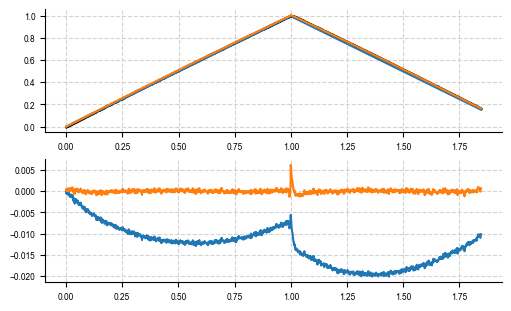

In [3]:
def get_slope(t: Float[Array, " N"], x: Float[Array, " N"]):
    return (x[-1] - x[0]) / (t[-1] - t[0])


v_approx = 0.5 * (
    get_slope(dataset.approach.time, dataset.approach.depth)
    - get_slope(dataset.retract.time, dataset.retract.depth)
)

indentation_linear = (
    IndentationBuilder(enforce_continuity=True)
    .append(ConstantVelocity(v_approx), duration=dataset.approach.time[-1])
    .append(
        ConstantVelocity(-v_approx),
        duration=dataset.retract.time[-1] - dataset.approach.time[-1],
    )
    .build()
)

fig, axes = plt.subplots(2, 1, figsize=(5, 3))
axes[0].plot(dataset.total_time, dataset.total_depth, ".", color="k")
axes[0].plot(
    dataset.total_time,
    indentation_linear.depth(dataset.total_time),
    label="Constant velocity",
)
axes[0].plot(
    dataset.total_time, indentation.depth(dataset.total_time), label="Cubic spline"
)

axes[1].plot(
    dataset.total_time[1:],
    (
        (indentation_linear.depth(dataset.total_time) - dataset.total_depth)
        # / dataset.total_depth
    )[1:],
    label="Constant velocity",
)
axes[1].plot(
    dataset.total_time[1:],
    (
        (indentation.depth(dataset.total_time) - dataset.total_depth)
        # / dataset.total_depth
    )[1:],
    label="Cubic spline",
)

In [4]:
@eqx.filter_jit
def residual_pl(constit: PowerLaw, args) -> PyTree[Array]:
    indentation, tip, dataset = args
    force_pred = force_powerlaw(dataset.total_time, constit, indentation, tip)
    return force_pred - dataset.total_force

In [21]:
bounds = (
    PowerLaw(0.0, 0.0),
    PowerLaw(jnp.inf, 1.0),
)
y0 = PowerLaw(10.0, 0.2)

to_bounded, to_unbounded = make_transformation_function(bounds)

y_unbounded = eqx.filter_jit(to_unbounded)(y0)
print(y_unbounded.E0, y_unbounded.alpha)

y_bounded = eqx.filter_jit(to_bounded)(y_unbounded)
print(y_bounded.E0, y_bounded.alpha)

10.954451150103322 -0.6435011087932844
10.0 0.2


In [22]:
args = (indentation_linear, tip, dataset)
sol = least_squares(residual_pl, y0, args, bounds)
print(sol.value.E0, sol.value.alpha)

2024-09-02 14:45:00.548299: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
/home/jhko725/mambaforge/envs/blackjax/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(


{'max_steps': 256, 'num_steps': Array(14, dtype=int64, weak_type=True)}
0.4388103062490909 0.08074977909275693


In [ ]:
# f_pred_app = force_ting(dataset.total_time, sol_app.value, indentation, tip)
f_pred = force_powerlaw(dataset.total_time, sol.value, indentation_linear, tip)

In [8]:
residual_dict = dict()

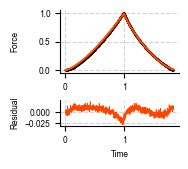

In [9]:
fig, axes = plt.subplots(
    2, 1, figsize=(45 * MM, 40 * MM), gridspec_kw=dict(height_ratios=(2.5, 1))
)
ax = axes[0]
ax.plot(
    dataset.total_time,
    dataset.total_force,
    ".",
    color="k",
    label="Data",
    markersize=0.5,
)


ax.plot(dataset.total_time, f_pred, color="orangered", label="Total")
# ax.plot(dataset.total_time, f_pred_app, "--", label="Approach", alpha=0.7)
# ax.legend()
ax.set_ylabel("Force")

residual_dict["Power law"] = f_pred - dataset.total_force
ax = axes[1]
ax.plot(
    dataset.total_time,
    residual_dict["Power law"],
    color="orangered",
    label="Total",
    linewidth=0.5,
)
# ax.plot(
#     dataset.total_time,
#     f_pred_app - dataset.total_force,
#     label="Approach",
#     linewidth=0.5,
#     alpha=0.7,
# )
ax.set_ylabel("Residual")

axes[-1].set_xlabel("Time")
fig.align_ylabels()
fig.savefig("../figures/temp.pdf", format="pdf", dpi=1200)
# fig.suptitle("Model: Standard Linear Solid (SLS)")

In [5]:
@eqx.filter_jit
def residual(constit: AbstractConstitutive, args) -> PyTree[Array]:
    indentation, tip, dataset = args
    f_app_pred = force_approach(dataset.t_app, constit, indentation, tip)
    f_ret_pred = force_retract(dataset.t_ret, constit, indentation, tip)
    return jnp.concatenate((f_app_pred - dataset.f_app, f_ret_pred - dataset.f_ret))


@eqx.filter_jit
def residual_app(constit: AbstractConstitutive, args) -> PyTree[Array]:
    indentation, tip, dataset = args
    f_app_pred = force_approach(dataset.t_app, constit, indentation, tip)
    return f_app_pred - dataset.f_app

In [6]:
import numpy as np


def make_residual(indentation, tip, dataset):
    f_app, f_ret = dataset.f_app, dataset.f_ret

    def _residual(constit, args):
        del args
        f_app_pred = force_approach(dataset.t_app, constit, indentation, tip)
        f_ret_pred = force_retract(dataset.t_ret, constit, indentation, tip)
        return jnp.concatenate((f_app_pred - f_app, f_ret_pred - f_ret))

    return _residual


args = (indentation, tip, dataset)
residual_func = make_residual(*args)

In [9]:
bounds = (
    ModifiedPowerLaw(0.0, 0.0, 0.0),
    ModifiedPowerLaw(jnp.inf, 1.0, jnp.inf),
)
y0 = ModifiedPowerLaw(1.0, 0.5, 1.0)
sol_jaxopt = least_squares(
    residual_func, y0, args, bounds, backend="jaxopt", method="trf"
)

In [8]:
sol_optx = least_squares(
    residual_func, y0, args, bounds, backend="optimistix", method="levenbergmarquardt"
)

/home/jhko725/mambaforge/envs/blackjax/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(


{'max_steps': 256, 'num_steps': Array(46, dtype=int64, weak_type=True)}


In [13]:
import dataclasses

print(dataclasses.asdict(sol_jaxopt.value))
print(dataclasses.asdict(sol_optx.value))

{'E0': Array(0.63490202, dtype=float64), 'alpha': Array(0.092909, dtype=float64), 't0': Array(0.0136246, dtype=float64)}
{'E0': Array(0.63488578, dtype=float64), 'alpha': Array(0.09291131, dtype=float64), 't0': Array(0.01362959, dtype=float64)}


In [24]:
sol = curve_fit(residual_func, y0, args, bounds, max_steps=100)

/home/jhko725/mambaforge/envs/blackjax/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(


In [30]:
print(lbfgsb_sol.E0, lbfgsb_sol.alpha, lbfgsb_sol.t0)
print(sol.value.E0, sol.value.alpha, sol.value.t0)

0.7665467364979118 0.08085643350633502 0.0009860504342345047
0.7660992876808275 0.08090707965746147 0.0009972299468505863


In [17]:
samples = sample_params_lhs(
    10, ([1e-3, 0.0, 1e-3], [1e2, 1.0, 1e2]), scale=["log", "linear", "log"]
)

In [18]:
from tqdm import tqdm
import jax

args = (indentation, tip, dataset)
sols = []
bounds = (
    ModifiedPowerLaw(0.0, 0.0, 0.0),
    ModifiedPowerLaw(jnp.inf, 1.0, jnp.inf),
)
batch_size = 5
n_batches = len(samples) // batch_size
sols_batch = []


def helper(y0):
    return curve_fit(residual_func, y0, args, bounds, throw=False)


for i in tqdm(range(n_batches)):
    samples_batch = jnp.stack(samples[i : i + batch_size], axis=-1)
    y0_batch = eqx.filter_vmap(ModifiedPowerLaw)(*samples_batch)
    sol_batch = eqx.filter_vmap(helper)(y0_batch)
    sols_batch.append(sol_batch)

  0%|          | 0/2 [00:00<?, ?it/s]

/home/jhko725/mambaforge/envs/blackjax/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
 50%|█████     | 1/2 [01:16<01:16, 76.37s/it]/home/jhko725/mambaforge/envs/blackjax/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
100%|██████████| 2/2 [02:33<00:00, 76.82s/it]


In [23]:
dynamic, static = eqx.partition(sols_batch[0], eqx.is_array)
dynamic_batch = [eqx.partition(s, eqx.is_array)[0] for s in sols_batch]
dynamic_total = jax.tree.map(lambda *args: jnp.concatenate(args), *dynamic_batch)
sols_total = eqx.combine(dynamic_total, static)

In [25]:
sol

Solution(
  value=ModifiedPowerLaw(E0=f64[], alpha=f64[], t0=f64[]),
  result=EnumerationItem(
    _value=i32[],
    _enumeration=<class 'optimistix._solution.RESULTS'>
  ),
  aux=None,
  stats={'max_steps': 100, 'num_steps': i64[]},
  state=_GaussNewtonState(
    first_step=bool[],
    y_eval=ModifiedPowerLaw(E0=f64[], alpha=f64[], t0=f64[]),
    search_state=_TrustRegionState(step_size=f64[]),
    f_info=ResidualJac(
      residual=f64[1464],
      jac=FunctionLinearOperator(
        fn=_ClosureConvert(
          jaxpr={ lambda a:f64[793,3] b:f64[] c:f64[] d:f64[] e:f64[] f:f64[] g:f64[671,3] h:f64[671]
    i:f64[671,3] j:bool[671] k:f64[671]; l:f64[] m:f64[] n:f64[]. let
    o:f64[1464] = pjit[
      name=objective_fn_unbounded
      jaxpr={ lambda ; p:f64[] q:f64[] r:f64[] s:f64[793,3] t:f64[] u:f64[] v:f64[]
          w:f64[] x:f64[] y:f64[671,3] z:f64[671] ba:f64[671,3] bb:bool[671] bc:f64[671]. let
          bd:f64[] = mul p t
          be:f64[] = mul bd u
          bf:f64[1] = 

In [33]:
dynamic, static = eqx.partition(sols_total, eqx.is_array)
dynamic_vals, treedef = jax.tree.flatten(dynamic)
dynamic_list = [list(args) for args in zip(dynamic_vals)]
dynamic_list

[[Array([ 0.63486463,  0.634927  ,  0.86581706,  0.63491797,  0.63488563,
          0.634927  ,  0.86581706,  0.63491797,  0.63488563,  0.63486585,
          0.86581706,  0.63491797,  0.63488563,  0.63486585,  0.63488488,
          0.63491797,  0.63488563,  0.63486585,  0.63488488,  0.63486105,
          0.63488563,  0.63486585,  0.63488488,  0.63486105,  0.63486093,
          0.63486585,  0.63488488,  0.63486105,  0.63486093,  0.63487061,
          0.63488488,  0.63486105,  0.63486093,  0.63487061,  1.01302935,
          0.63486105,  0.63486093,  0.63487061,  1.01302935,  0.63488324,
          0.63486093,  0.63487061,  1.01302935,  0.63488324,  0.63492124,
          0.63487061,  1.01302935,  0.63488324,  0.63492124,  0.63488078,
          1.01302935,  0.63488324,  0.63492124,  0.63488078,  0.45906141,
          0.63488324,  0.63492124,  0.63488078,  0.45906141,  0.63488094,
          0.63492124,  0.63488078,  0.45906141,  0.63488094,  0.63488441,
          0.63488078,  0.45906141,  0.

In [38]:
bics = jnp.asarray(
    [bayesian_information_criterion(residual, sol.value, args) for sol in sols]
)

In [48]:
print(bics)

[-23640.41653668 -23640.4166251  -23640.41613802 -19317.38658196
 -23640.41613944 -23640.41588811 -23640.41609084 -23640.41581429
 -23640.41599105 -23640.41665167]


In [40]:
sol_best = sols[jnp.argmin(bics)]

In [ ]:
sol_batched = eqx.filter_jit(eqx.filter_vmap(curve_fit, in_axes=(None, 0, None, None)))(
    residual, y0_batch, args, bounds
)

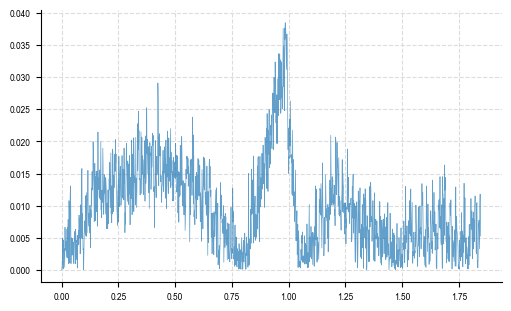

In [50]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
for sol in sols[9:]:
    ax.plot(
        dataset.total_time, jnp.abs(residual(sol.value, args)), linewidth=0.5, alpha=0.7
    )

## Define residual function for the least squares curve fit

In [12]:
@eqx.filter_jit
def residual(constit: AbstractConstitutive, args) -> PyTree[Array]:
    indentation, tip, dataset = args
    f_app_pred = force_approach(dataset.t_app, constit, indentation, tip)
    f_ret_pred = force_retract(dataset.t_ret, constit, indentation, tip)
    return jnp.concatenate((f_app_pred - dataset.f_app, f_ret_pred - dataset.f_ret))


@eqx.filter_jit
def residual_app(constit: AbstractConstitutive, args) -> PyTree[Array]:
    indentation, tip, dataset = args
    f_app_pred = force_approach(dataset.t_app, constit, indentation, tip)
    return f_app_pred - dataset.f_app

In [150]:
count_free_params(StandardLinearSolid(0.0, 0.0, 0.0))

3

In [34]:
bounds = (
    StandardLinearSolid(0.0, 0.0, 0.0),
    StandardLinearSolid(jnp.inf, jnp.inf, jnp.inf),
)
y0 = StandardLinearSolid(10.0, 10.0, 10.0)

to_bounded, to_unbounded = make_transformation_function(bounds)

In [117]:
y_unbounded = eqx.filter_jit(to_unbounded)(y0)
print(y_unbounded.E1, y_unbounded.E_inf, y_unbounded.tau)

10.954451150103322 10.954451150103322 10.954451150103322


In [8]:
y_bounded = eqx.filter_jit(to_bounded)(y_unbounded)
print(y_bounded.E1, y_bounded.E_inf, y_bounded.tau)

10.0 10.0 10.0


In [35]:
args = (indentation, tip, dataset)
sol_app = curve_fit(residual_app, y0, args, bounds)
print(sol_app.value.E1, sol_app.value.E_inf, sol_app.value.tau)

9.675149570398389e-12 0.4888074511358822 9.770589588054525


In [36]:
args = (indentation, tip, dataset)
sol = curve_fit(residual, y0, args, bounds)
print(sol.value.E1, sol.value.E_inf, sol.value.tau)

0.5205142075518838 4.956211978601743e-07 5.134753023848408


In [37]:
f_pred_app = force_ting(dataset.total_time, sol_app.value, indentation, tip)
f_pred = force_ting(dataset.total_time, sol.value, indentation, tip)

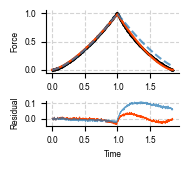

In [38]:
fig, axes = plt.subplots(
    2, 1, figsize=(45 * MM, 40 * MM), gridspec_kw=dict(height_ratios=(2.5, 1))
)
ax = axes[0]
ax.plot(
    dataset.total_time,
    dataset.total_force,
    ".",
    color="k",
    label="Data",
    markersize=0.5,
)


ax.plot(dataset.total_time, f_pred, color="orangered", label="Total")
ax.plot(dataset.total_time, f_pred_app, "--", label="Approach", alpha=0.7)
# ax.legend()
ax.set_ylabel("Force")

residual_dict["Standard Linear Solid"] = f_pred - dataset.total_force
ax = axes[1]
ax.plot(
    dataset.total_time,
    residual_dict["Standard Linear Solid"],
    color="orangered",
    label="Total",
    linewidth=0.5,
)
ax.plot(
    dataset.total_time,
    f_pred_app - dataset.total_force,
    label="Approach",
    linewidth=0.5,
    alpha=0.7,
)
ax.set_ylabel("Residual")

axes[-1].set_xlabel("Time")
fig.align_ylabels()
fig.savefig("../figures/temp.pdf", format="pdf", dpi=1200)
# fig.suptitle("Model: Standard Linear Solid (SLS)")

In [24]:
bounds = (
    ModifiedPowerLaw(0.0, 0.0, 0.0),
    ModifiedPowerLaw(jnp.inf, 1.0, jnp.inf),
)
y0 = ModifiedPowerLaw(1.0, 0.4, 1.0)
print(y0.E0, y0.alpha, y0.t0)

to_bounded, to_unbounded = make_transformation_function(bounds)
y_unbounded = to_unbounded(y0)
print(y_unbounded.E0, y_unbounded.alpha, y_unbounded.t0)
y_bounded = to_bounded(y_unbounded)
print(y_bounded.E0, y_bounded.alpha, y_bounded.t0)

1.0 0.4 1.0
1.7320508075688772 -0.20135792079033074 1.7320508075688772
0.9999999999999998 0.4 0.9999999999999998


In [139]:
y0_batch = eqx.filter_vmap(ModifiedPowerLaw)(
    jnp.asarray([0.1, 1.0, 2.0, 3.0] * 10),
    jnp.asarray([0.1, 0.2, 0.3, 0.4] * 10),
    jnp.asarray([0.1, 10.0, 2.0, 1e-2] * 10),
)
sol_batched = eqx.filter_jit(eqx.filter_vmap(curve_fit, in_axes=(None, 0, None, None)))(
    residual, y0_batch, args, bounds
)

ConcretizationTypeError: Abstract tracer value encountered where concrete value is expected: traced array with shape float64[].
The problem arose with the `float` function. If trying to convert the data type of a value, try using `x.astype(float)` or `jnp.array(x, float)` instead.
The error occurred while tracing the function curve_fit at /home/jhko725/mambaforge/envs/blackjax/lib/python3.12/site-packages/equinox/_jit.py:37 for jit. 

See https://jax.readthedocs.io/en/latest/errors.html#jax.errors.ConcretizationTypeError

In [138]:
print(sol_batched.value.E0, sol_batched.value.alpha, sol_batched.value.t0)

[0.63489239 0.63486598 0.63486105 0.94210654 0.63489239 0.63486598
 0.63486105 0.94210654 0.63489239 0.63486598 0.63486105 0.94210654
 0.63489239 0.63486598 0.63486105 0.94210654 0.63489239 0.63486598
 0.63486105 0.94210654 0.63489239 0.63486598 0.63486105 0.94210654
 0.63489239 0.63486598 0.63486105 0.94210654 0.63489239 0.63486598
 0.63486105 0.94210654 0.63489239 0.63486598 0.63486105 0.94210654
 0.63489239 0.63486598 0.63486105 0.94210654] [0.09291042 0.09291445 0.0929152  0.08536774 0.09291042 0.09291445
 0.0929152  0.08536774 0.09291042 0.09291445 0.0929152  0.08536774
 0.09291042 0.09291445 0.0929152  0.08536774 0.09291042 0.09291445
 0.0929152  0.08536774 0.09291042 0.09291445 0.0929152  0.08536774
 0.09291042 0.09291445 0.0929152  0.08536774 0.09291042 0.09291445
 0.0929152  0.08536774 0.09291042 0.09291445 0.0929152  0.08536774
 0.09291042 0.09291445 0.0929152  0.08536774] [1.36276970e-02 1.36363511e-02 1.36379473e-02 9.16776024e-05
 1.36276970e-02 1.36363511e-02 1.36379473e-

In [25]:
args = (indentation, tip, dataset)
sol_app = curve_fit(residual_app, y0, args, bounds)
print(sol_app.value.E0, sol_app.value.alpha, sol_app.value.t0)

0.488807451165854 2.0451623727879564e-10 1.2893814119888418


In [26]:
sol = curve_fit(residual, y0, args, bounds)
print(sol.value.E0, sol.value.alpha, sol.value.t0)

0.6348862791837833 0.09291134441218196 0.013629781374266736


In [41]:
# f_pred_app = force_ting(dataset.total_time, sol_app.value, indentation, tip)
f_pred = force_ting(dataset.total_time, sol_best.value, indentation, tip)

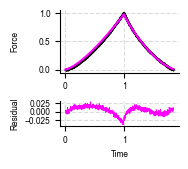

In [43]:
fig, axes = plt.subplots(
    2, 1, figsize=(45 * MM, 40 * MM), gridspec_kw=dict(height_ratios=(2.5, 1))
)
ax = axes[0]
ax.plot(
    dataset.total_time,
    dataset.total_force,
    ".",
    color="k",
    label="Data",
    markersize=0.5,
)
residual_dict = dict()

ax.plot(dataset.total_time, f_pred, color="magenta", label="Total")
# ax.plot(dataset.total_time, f_pred_app, "--", label="Approach", alpha=0.7)
# ax.legend()
ax.set_ylabel("Force")
residual_dict["Modified Power Law"] = f_pred - dataset.total_force
ax = axes[1]
ax.plot(
    dataset.total_time,
    residual_dict["Modified Power Law"],
    color="magenta",
    label="Total",
    linewidth=0.5,
)

# ax.plot(
#     dataset.total_time,
#     f_pred_app - dataset.total_force,
#     label="Approach",
#     linewidth=0.5,
#     alpha=0.7,
# )
ax.set_ylabel("Residual")

axes[-1].set_xlabel("Time")
fig.align_ylabels()
# fig.suptitle("Model: Modified Power Law (SLS)")
fig.savefig("../figures/temp.pdf", format="pdf", dpi=1200)

In [17]:
bounds = (
    GeneralizedMaxwellmodel(0.0, 0.0, 0.0, 0.0, 0.0),
    GeneralizedMaxwellmodel(jnp.inf, jnp.inf, jnp.inf, jnp.inf, jnp.inf),
)
y0 = GeneralizedMaxwellmodel(1.0, 2.0, 3.0, 4.0, 5.0)

to_bounded, to_unbounded = make_transformation_function(bounds)

sol_jaxopt = least_squares(
    residual_func, y0, args, bounds, backend="jaxopt", method="trf"
)

In [18]:
sol_optx = least_squares(
    residual_func, y0, args, bounds, backend="optimistix", method="levenbergmarquardt"
)

/home/jhko725/mambaforge/envs/blackjax/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(


{'max_steps': 256, 'num_steps': Array(83, dtype=int64, weak_type=True)}


In [19]:
print(dataclasses.asdict(sol_jaxopt.value))
print(dataclasses.asdict(sol_optx.value))

{'E1': Array(0.12934413, dtype=float64), 'E2': Array(0.32460302, dtype=float64), 'E_inf': Array(0.14085847, dtype=float64), 'tau1': Array(0.15625678, dtype=float64), 'tau2': Array(7.93678342, dtype=float64)}
{'E1': Array(0.12704656, dtype=float64), 'E2': Array(0.18957147, dtype=float64), 'E_inf': Array(0.2785031, dtype=float64), 'tau1': Array(0.15251358, dtype=float64), 'tau2': Array(4.08811025, dtype=float64)}


In [44]:
f_pred = force_ting(dataset.total_time, sol.value, indentation, tip)

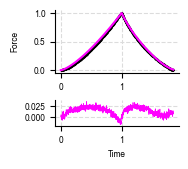

In [45]:
fig, axes = plt.subplots(
    2, 1, figsize=(45 * MM, 40 * MM), gridspec_kw=dict(height_ratios=(2.5, 1))
)
ax = axes[0]
ax.plot(
    dataset.total_time,
    dataset.total_force,
    ".",
    color="k",
    label="Data",
    markersize=0.5,
)


ax.plot(dataset.total_time, f_pred, color="magenta", label="Total")
# ax.plot(dataset.total_time, f_pred_app, "--", label="Approach", alpha=0.7)
# ax.legend()
ax.set_ylabel("Force")
residual_dict["Generalized Maxwell"] = f_pred - dataset.total_force
ax = axes[1]
ax.plot(
    dataset.total_time,
    residual_dict["Generalized Maxwell"],
    color="magenta",
    label="Total",
    linewidth=0.5,
)

# ax.plot(
#     dataset.total_time,
#     f_pred_app - dataset.total_force,
#     label="Approach",
#     linewidth=0.5,
#     alpha=0.7,
# )
# ax.set_ylabel("Residual")

axes[-1].set_xlabel("Time")
fig.align_ylabels()
# fig.suptitle("Model: Modified Power Law (SLS)")
# fig.savefig("../figures/temp.pdf", format="pdf", dpi=1200)

In [12]:
bounds = (
    DoublePowerLaw(0.0, 0.0, 0.0, 0.0),
    DoublePowerLaw(jnp.inf, 1.0, jnp.inf, 1.0),
)
y0 = DoublePowerLaw(1.0, 0.2, 3.0, 0.3)
args = (indentation, tip, dataset)
to_bounded, to_unbounded = make_transformation_function(bounds)

sol = curve_fit(residual, y0, args, bounds, max_steps=1000)
print(sol.value.E0, sol.value.alpha, sol.value.E1, sol.value.beta)

In [ ]:
f_pred = force_ting(dataset.total_time, sol.value, indentation, tip)

In [ ]:
plt.plot(dataset.total_time, jnp.abs(f_pred - dataset.total_force))

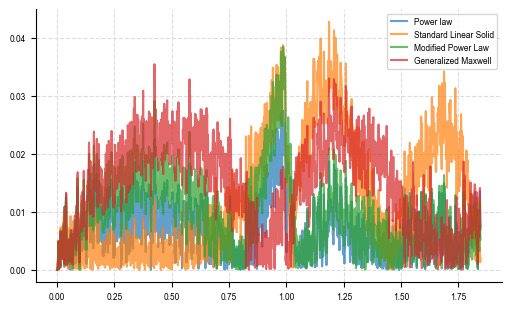

In [46]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
for k, v in residual_dict.items():
    ax.plot(dataset.total_time, jnp.abs(v), label=k, alpha=0.7)
ax.legend()